Columns in dataset:
['RowNumber', 'CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Columns after dropping:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7874 - loss: 0.5430 - val_accuracy: 0.7975 - val_loss: 0.5023 - learning_rate: 0.0010
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7985 - loss: 0.4827 - val_accuracy: 0.8050 - val_loss: 0.4602 - learning_rate: 0.0010
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8098 - loss: 0.4504 - val_accuracy: 0.8135 - val_loss: 0.4365 - learning_rate: 0.0010
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8160 - loss: 0.4357 - val_accuracy: 0.8200 - val_loss: 0.4264 - learning_rate: 0.0010
Epoch 5/100
250/250 ━━━━━━━━

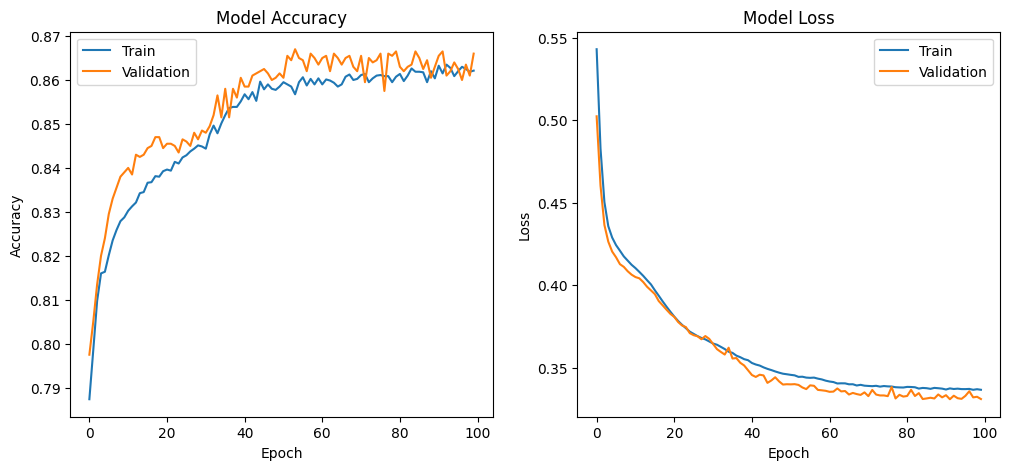

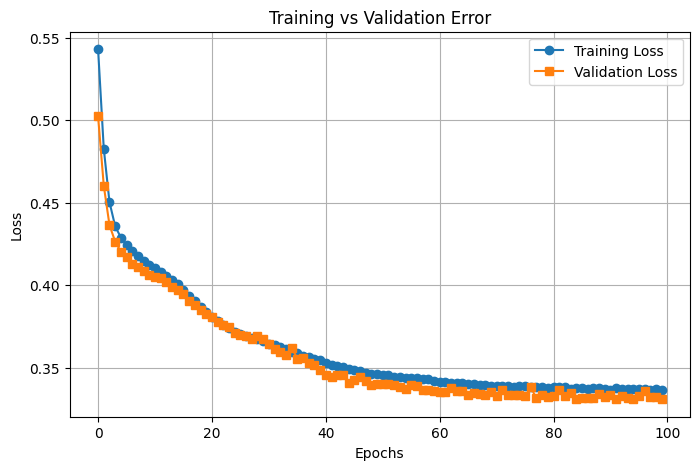

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf

# =========================
# Load Dataset
# =========================

df = pd.read_csv("Churn_Modelling.csv")

print("Columns in dataset:")
print(df.columns.tolist())

# =========================
# Drop unnecessary columns
# =========================

cols_to_drop = ['RowNumber', 'CustomerId', 'Surname']

for col in cols_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

print("\nColumns after dropping:")
print(df.columns.tolist())

# =========================
# Encode categorical data
# =========================

from sklearn.preprocessing import LabelEncoder

le_geo = LabelEncoder()
le_gender = LabelEncoder()

if 'Geography' in df.columns:
    df['Geography'] = le_geo.fit_transform(df['Geography'])

if 'Gender' in df.columns:
    df['Gender'] = le_gender.fit_transform(df['Gender'])

# =========================
# Features and Target
# =========================

X = df.drop('Exited', axis=1)
y = df['Exited']

# =========================
# Split Dataset
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

# =========================
# Feature Scaling
# =========================

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# =========================
# Build ANN
# =========================

ann = tf.keras.models.Sequential()

ann.add(tf.keras.layers.Dense(units=6, activation='relu'))
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

# =========================
# Compile ANN
# =========================

ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================
# Callbacks
# =========================

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=10,
    min_lr=0.0001
)

# =========================
# Train ANN
# =========================

history = ann.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr]
)

# =========================
# Single Prediction
# =========================

sample = pd.DataFrame(
    [[600, 0, 1, 40, 3, 60000, 2, 1, 1, 50000]],
    columns=X.columns
)

sample_scaled = sc.transform(sample)

prediction = ann.predict(sample_scaled)

print("\nPrediction Probability:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Customer will leave the bank")
else:
    print("Customer will stay in the bank")

# =========================
# Test Predictions
# =========================

y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)

# =========================
# Evaluation
# =========================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    roc_auc_score
)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

print("\nAccuracy")
print(accuracy_score(y_test, y_pred))

# =========================
# Detailed Metrics
# =========================

train_loss, train_acc = ann.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = ann.evaluate(X_test, y_test, verbose=0)

y_train_pred = ann.predict(X_train)
train_auc = roc_auc_score(y_train, y_train_pred)

y_test_pred = ann.predict(X_test)
test_auc = roc_auc_score(y_test, y_test_pred)

print("\nTraining Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Test AUC:", test_auc)

# =========================
# Plot Accuracy & Loss
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()
import matplotlib.pyplot as plt
# Plot training vs validation error (loss)
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title("Training vs Validation Error")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
    